# DSP Exercise Set: Signals & Time-Domain Analysis

## Procesamiento Digital de Señales

### Facultad de ingenieria

Profesor: Oscar Francisco Fuentes Casarrubias



In [1]:
# === Datos del estudiante ===
NOMBRE = ["Hernández González Andrés Sebastian - 319328439", "Luna Reyes Javier - 319046351"]
GRUPO = 4

for nom in NOMBRE:
  print(f"Nombre: {nom}\n")
print("Grupo:", GRUPO)

Nombre: Hernández González Andrés Sebastian - 319328439

Nombre: Luna Reyes Javier - 319046351

Grupo: 4


Importacion de librerias necesarias para las graficas de la tarea y formato básico de graficas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 3)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=4, suppress=True)

Funciones de graficación (scaffold)

In [ ]:
def stem_plot(n, x, title="", xlabel="n", ylabel="x[n]"):
    """Discrete-time stem plot."""
    n = np.asarray(n)
    x = np.asarray(x)
    markerline, stemlines, baseline = plt.stem(n, x)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

def compare_stem(n, x1, x2, label1="x1", label2="x2", title=""):
    """Compare two discrete-time signals on the same axes."""
    n = np.asarray(n)
    x1 = np.asarray(x1); x2 = np.asarray(x2)
    plt.stem(n, x1, label=label1)
    plt.stem(n, x2, label=label2)
    plt.title(title)
    plt.xlabel("n")
    plt.ylabel("amplitud")
    plt.legend()
    plt.grid(True)
    plt.show()

Funciones implementadas sin atajos

In [ ]:
def time_reverse(x):
    """Return x_rev[n] = x[-n] assuming x is indexed on n=0..N-1 (finite-length)."""
    N = len(x)
    # Creamos un arreglo vacío del mismo tamaño
    x_rev = np.zeros(N)

    # Recorremos el arreglo original de izquierda a derecha.
    # El elemento en la posición 'i' debe ir a la posición simétrica opuesta,
    # que se calcula como (N - 1 - i).
    for i in range(N):
        x_rev[i] = x[N - 1 - i]

    return x_rev

def time_shift(x, k, pad_value=0.0):
    """Return x_shift[n] = x[n-k]. Positive k shifts RIGHT (delay)."""
    N = len(x)
    # Inicializamos el arreglo con el valor de padding explícito
    x_shift = np.full(N, pad_value, dtype=float)

    # Iteramos sobre los índices originales.
    # El elemento x[i] debe moverse a la nueva posición (i + k).
    # Solo copiamos el valor si el nuevo índice cae dentro de los límites del arreglo [0, N-1].
    for i in range(N):
        new_index = i + k
        if 0 <= new_index < N:
            x_shift[new_index] = x[i]

    return x_shift

def energy(x):
    """E = sum |x[n]|^2 for the available samples."""
    E = 0.0
    # La energía es la sumatoria del cuadrado de cada muestra.
    # Iteramos directamente sobre los valores, los elevamos al cuadrado y acumulamos.
    for val in x:
        E += val ** 2
    return E

def mean_value(x):
    """Mean over available samples."""
    N = len(x)
    if N == 0:
        return 0.0

    suma = 0.0
    # Sumamos todas las muestras una por una y dividimos
    # entre el número total de muestras (N).
    for val in x:
        suma += val

    return suma / N

def rms(x):
    """RMS over available samples."""
    N = len(x)
    if N == 0:
        return 0.0

    suma_cuadrados = 0.0
    # Calculamos primero la suma de los cuadrados (Square).
    for val in x:
        suma_cuadrados += val ** 2

    # Luego dividimos entre N para sacar la media (Mean).
    mean_squares = suma_cuadrados / N

    # Finalmente sacamos la raíz cuadrada (Root) elevando a la 0.5.
    return mean_squares ** 0.5

def crosscorr(x, y):
    """Cross-correlation r_xy[k] for lags k = -(N-1)..(N-1). Return (k_vals, rxy)."""
    N = len(x)
    # Los retardos (lags) van desde -(N-1) hasta (N-1) asumiendo igual longitud
    min_k = -(N - 1)
    max_k = N - 1

    k_vals = []
    rxy_vals = []

    # Para calcular la correlación R_xy[k] = sum(x[n] * y[n-k]),
    # necesitamos un ciclo exterior para cada retardo 'k', y un ciclo interior
    # 'n' que recorre la señal 'x' calculando el solapamiento con 'y'.
    for k in range(min_k, max_k + 1):
        suma_productos = 0.0

        for n in range(N):
            idx_y = n - k
            # Comprobamos que el índice desplazado exista dentro de los límites de y
            if 0 <= idx_y < N:
                suma_productos += x[n] * y[idx_y]

        # Guardamos el retardo y el resultado de la sumatoria
        k_vals.append(k)
        rxy_vals.append(suma_productos)

    return np.array(k_vals), np.array(rxy_vals)

def autocorr(x):
    """Autocorrelation for lags k = -(N-1)..(N-1). Return (k_vals, rxx)."""
    # Matemáticamente, la autocorrelación es simplemente la correlación cruzada de una señal consigo misma.
    return crosscorr(x, x)

#Exercise 1
Para -5 ≤ n ≤ 5, construye y grafica:

*   a) u[n]
*   b) δ[n]
*   c) r[n] = n u[n]




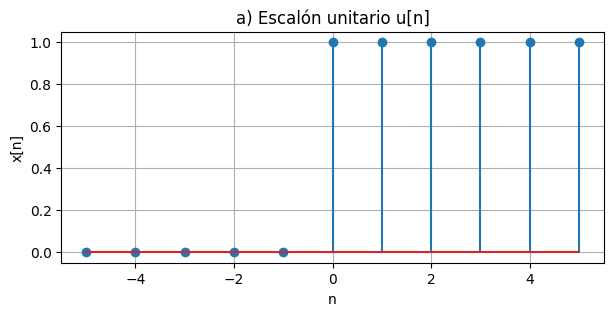

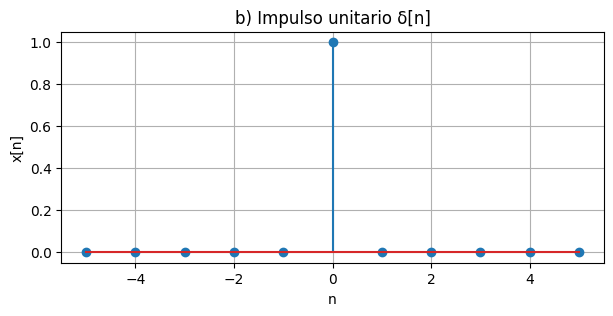

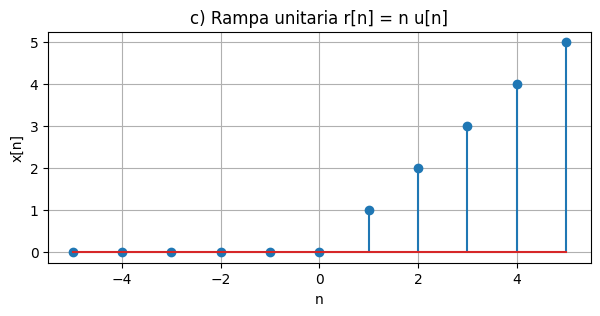

In [ ]:
# Definimos el vector de tiempo discreto desde -5 hasta 5
n = np.arange(-5, 6)

# a) Escalón unitario u[n]
# La función escalón "se enciende" en n = 0. Por definición vale 1 si n >= 0, y 0 en cualquier otro caso.
# Iteramos sobre nuestro vector 'n' evaluando esta condición matemática.
u = np.array([1.0 if val >= 0 else 0.0 for val in n])

# b) Impulso unitario δ[n]
# La función impulso solo existe y vale 1 exactamente en el origen (n = 0).
# Para todos los demás instantes de tiempo, vale 0.
delta = np.array([1.0 if val == 0 else 0.0 for val in n])

# c) Rampa unitaria r[n] = n u[n]
# La rampa crece linealmente de forma idéntica a 'n', pero solo en la parte causal (n >= 0).
# Al multiplicar elemento a elemento el vector 'n' por el vector escalón 'u',podemos forzamor a 0 toda la parte negativa y conservamos los valores originales en la positiva.
r = n * u

# Graficar y verificar visualmente
stem_plot(n, u, title="a) Escalón unitario u[n]")
stem_plot(n, delta, title="b) Impulso unitario δ[n]")
stem_plot(n, r, title="c) Rampa unitaria r[n] = n u[n]")

#Exercise 2
Periodicidad de x[n] = cos((5π/6)n)


1.   Determina si es periódica.
2.   Si lo es, encuentra su periodo fundamental N0.


TODO: explica en texto (markdown o comentarios) y verifica con una gráfica de varios periodos.


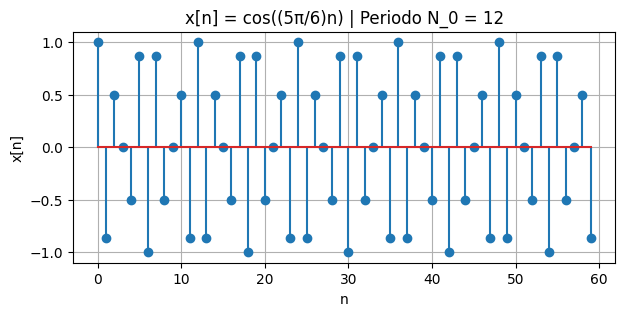

In [ ]:
# Verificación numérica y visual
# Graficaremos 60 muestras para poder observar varios periodos (60/12 = 5 periodos)
n = np.arange(0, 60)

# Calculamos los valores de la señal
x = np.cos((5 * np.pi / 6) * n)

# Graficamos
# Hay picos máximos (valor 1.0). Deben ocurrir exactamente en n=0, n=12, n=24, n=36 y n=48.
stem_plot(n, x, title="x[n] = cos((5π/6)n) | Periodo N_0 = 12")

#Exercise 3
Transformaciones en una secuencia finita
Dada: x[n] = {1,2,3,4} para n = 0,1,2,3

Calcula y grafica:

*   a) x[-n]
*   b) x[n-2]
*   d) x[-n+2]
*   e) x[3-n]

Nota: Define claramente tu eje n para cada resultado (con padding si hace falta).

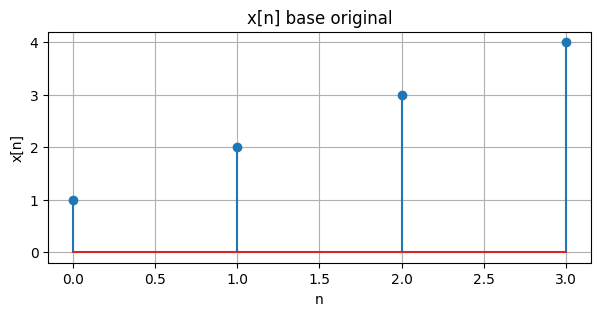

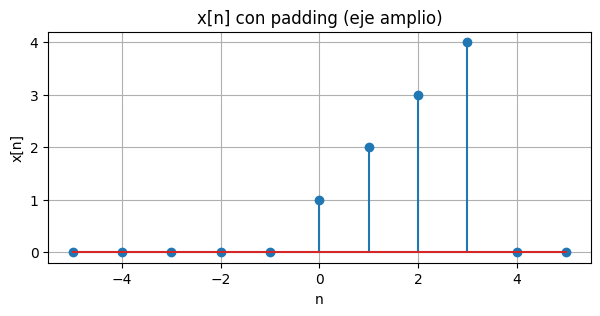

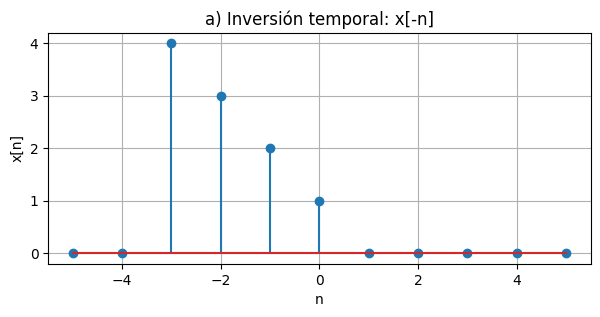

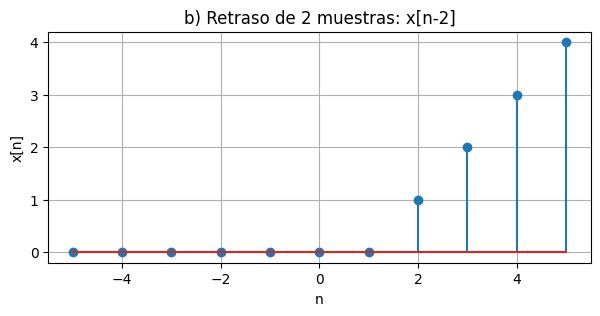

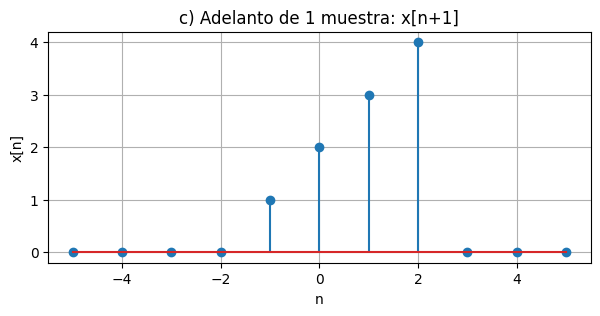

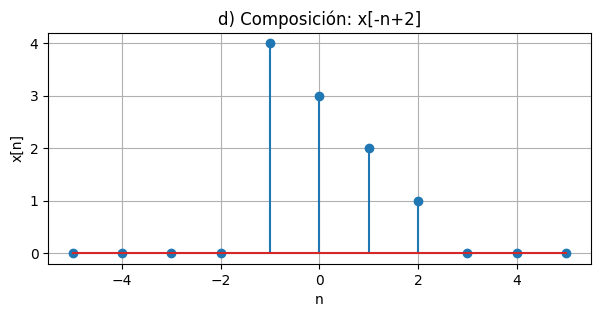

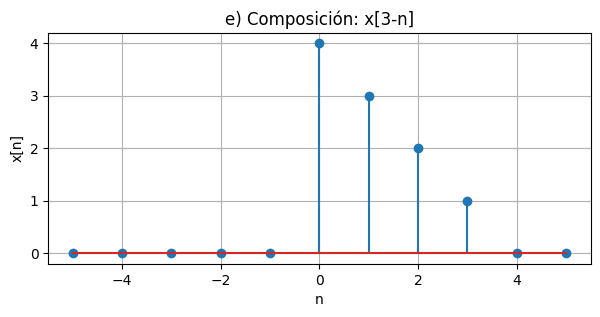

In [ ]:
# Señal base (dada)
x = np.array([1, 2, 3, 4], dtype=float)
n = np.arange(0, len(x))
stem_plot(n, x, title="x[n] base original")

# ESTRATEGIA DE PADDING (Relleno con ceros)

# Para evitar que las transformaciones recorten la señal al salirse de los límites de un arreglo de 4 elementos,
# definimos un eje 'n' más amplio, de -5 a 5.
n_pad = np.arange(-5, 6)
x_pad = np.zeros(len(n_pad))

# El índice central de n_pad (donde n=0) es 5.
# Copiamos la señal original en su lugar correspondiente (n=0 a n=3).
for i in range(len(x)):
    x_pad[5 + i] = x[i]

stem_plot(n_pad, x_pad, title="x[n] con padding (eje amplio)")

# a) Inversión temporal: x[-n]
# Llama a nuestra función. Como x_pad es simétrico respecto al centro (n=0 está a la mitad del arreglo), el reverso mantendrá
# correctamente el eje de tiempo alineado.
x_rev = time_reverse(x_pad)
stem_plot(n_pad, x_rev, title="a) Inversión temporal: x[-n]")

# b) Desplazamiento a la derecha: x[n-2]
# Un (n - 2) significa un retraso, lo que mueve la señal hacia la derecha en la gráfica (k = 2 positivo).
x_delay2 = time_shift(x_pad, 2)
stem_plot(n_pad, x_delay2, title="b) Retraso de 2 muestras: x[n-2]")

# c) Desplazamiento a la izquierda: x[n+1]
# Un (n + 1) es un adelanto, mueve la señal a la izquierda (k = -1 negativo).
x_adv1 = time_shift(x_pad, -1)
stem_plot(n_pad, x_adv1, title="c) Adelanto de 1 muestra: x[n+1]")

# Operaciones combinadas (Composiciones)

# d) x[-n+2]
# Por propiedades de señales, x[-n+2] equivale a x[-(n-2)].
# Esto significa que PRIMERO invertimos la señal, y LUEGO aplicamos
# un retraso de 2 unidades a esa señal invertida.
x_minus_n_plus_2 = time_shift(time_reverse(x_pad), 2)
stem_plot(n_pad, x_minus_n_plus_2, title="d) Composición: x[-n+2]")

# e) x[3-n]
# Se reescribe como x[-n+3] o x[-(n-3)]. Primero invertimos, luego retrasamos 3 unidades a la derecha.
x_3_minus_n = time_shift(time_reverse(x_pad), 3)
stem_plot(n_pad, x_3_minus_n, title="e) Composición: x[3-n]")

#Exercise 4
Energía, media y RMS
Para x[n] = {2, -2, 2, -2} (n=0..3):

Calcula la media
Calcula el RMS
Interpreta: ¿media = 0 implica RMS = 0? (explica)
TODO: Implementa usando tus funciones mean_value y rms.

In [ ]:
# Señal base
x = np.array([2, -2, 2, -2], dtype=float)

# Cálculos usando nuestras funciones base
# 1. mean_value sumará linealmente los elementos: 2 - 2 + 2 - 2 = 0, y dividirá entre 4.
# 2. rms primero elevará al cuadrado: 4, 4, 4, 4. Sumará: 16. Dividirá entre 4: 4. Entonces sacará la raíz cuadrada de 4, resultando en 2.
m = mean_value(x)
r = rms(x)

print("Señal x[n]:", x)
print("Media (Mean):", m)
print("Valor RMS:", r)

Señal x[n]: [ 2. -2.  2. -2.]
Media (Mean): 0.0
Valor RMS: 2.0


#Exercise 5
Energía (señal exponencial DT truncada)
Define una señal finita: x[n] = (0.9)^n u[n] para n = 0..30
1. Grafica x[n]
2. Calcula la energía aproximada en ese intervalo (truncado)
3. Explica qué pasaría si el intervalo fuera infinito (conceptual)

TODO: usa energy(x) y discute.

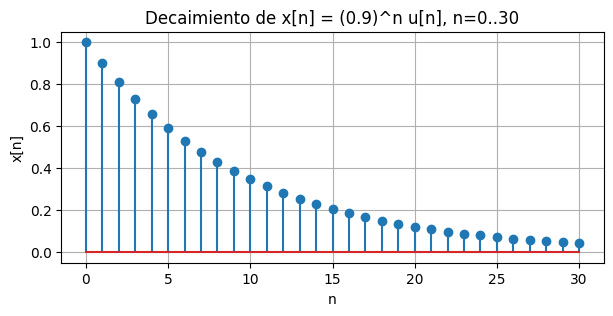

Energía (truncada n=0..30): 5.2555


In [ ]:
# 1. Definimos el intervalo truncado (ventana finita) n = 0..30
# arange(0, 31) genera los enteros del 0 al 30 inclusive.
n = np.arange(0, 31)

# 2. Construimos la señal
# Dado que nuestro vector 'n' solo contiene valores positivos o cero, la función escalón u[n] siempre vale 1.
# Por tanto, podemos evaluar (0.9)^n directamente.
x = 0.9**n

# 3. Graficamos la señal truncada
# Veremos una curva que decae exponencialmente hacia cero.
stem_plot(n, x, title="Decaimiento de x[n] = (0.9)^n u[n], n=0..30")

# 4. Calculamos la energía en este intervalo usando nuestra función base
E_trunc = energy(x)
print(f"Energía (truncada n=0..30): {E_trunc:.4f}")

#Exercise 6
Correlación (sin funciones mágicas)
x[n] = {1,2,1}
y[n] = {1,0,-1}

1. Calcula la autocorrelación r_xx[k]
2. Calcula la correlación cruzada r_xy[k]
3. Grafica r_xx[k] y r_xy[k] con eje de lags k.
TODO: implementa autocorr y crosscorr usando loops e índices.

Retardos k (Autocorr): [-2 -1  0  1  2]
r_xx[k]: [1. 4. 6. 4. 1.]


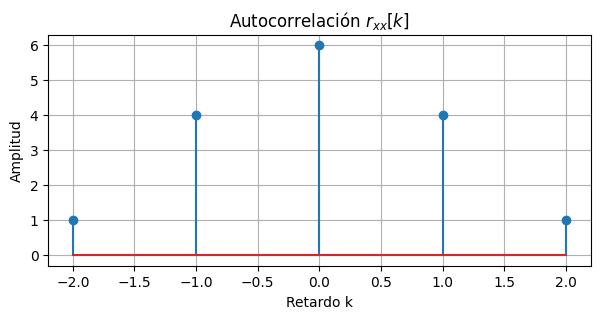

Retardos k (Crosscorr): [-2 -1  0  1  2]
r_xy[k]: [-1. -2.  0.  2.  1.]


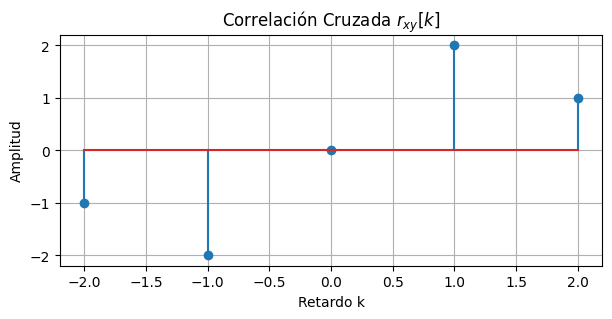

In [ ]:
# 1) Implementación de funciones con loops

def crosscorr(x, y):
    N = len(x)
    M = len(y)

    min_k = -(M - 1)
    max_k = N - 1

    k_vals = np.arange(min_k, max_k + 1)
    rxy = np.zeros(len(k_vals))

    # Recorremos cada retardo k posible
    for i, k in enumerate(k_vals):
        suma_productos = 0.0

        # Para un retardo k fijo, hacemos el producto punto deslizando la ventana
        for n in range(N):
            idx_y = n - k
            # Solo multiplicamos y sumamos si el índice desplazado de 'y' es válido (existe)
            if 0 <= idx_y < M:
                suma_productos += x[n] * y[idx_y]

        rxy[i] = suma_productos

    return k_vals, rxy

def autocorr(x):
    return crosscorr(x, x)

# 2) Aplicación a las señales del problema
x = np.array([1, 2, 1], dtype=float)
y = np.array([1, 0, -1], dtype=float)

# a) Autocorrelación
k_xx, rxx = autocorr(x)
print(f"Retardos k (Autocorr): {k_xx}")
print(f"r_xx[k]: {rxx}")
stem_plot(k_xx, rxx, title="Autocorrelación $r_{xx}[k]$", xlabel="Retardo k", ylabel="Amplitud")

# b) Correlación cruzada
k_xy, rxy = crosscorr(x, y)
print(f"Retardos k (Crosscorr): {k_xy}")
print(f"r_xy[k]: {rxy}")
stem_plot(k_xy, rxy, title="Correlación Cruzada $r_{xy}[k]$", xlabel="Retardo k", ylabel="Amplitud")


## 🔊 Sección Audio (extensión opcional)

**Idea:** Graba audio (con tu celular, Audacity, etc.), guarda un `.wav` y súbelo al notebook.

- En **Colab**: usa `files.upload()` (celda siguiente).
- En **Jupyter local**: coloca el `.wav` en la misma carpeta del notebook y pon el nombre en `wav_path`.

> Esta sección es para experimentar con **señales reales** usando las mismas operaciones DT.


In [ ]:
# === (Colab) Subir WAV (MISMO PATRÓN DEL EJEMPLO) ===
from google.colab import files
uploaded = files.upload()  # elige tu archivo .wav

# TODO: escribe EXACTAMENTE el nombre del archivo que subiste (tal como aparece arriba)
wav_path = "Voz-002.wav"

print("Usando wav_path =", wav_path)

Saving Voz-002.wav to Voz-002.wav
Usando wav_path = Voz-002.wav


In [ ]:

# === Cargar WAV (se mantiene simple y robusto) ===
# Intentamos soundfile primero; si no está, usamos scipy.io.wavfile.
fs = None
audio = None

audio_loaded = False

try:
    import soundfile as sf
    audio, fs = sf.read(wav_path, dtype="float32", always_2d=False)
    audio_loaded = True
except Exception as e:
    print("soundfile falló o no está instalado:", e)

if not audio_loaded:
    try:
        from scipy.io import wavfile
        fs, audio_int = wavfile.read(wav_path)

        # Si es estéreo, toma un canal (puedes cambiarlo)
        if hasattr(audio_int, "ndim") and audio_int.ndim > 1:
            audio_int = audio_int[:, 0]

        # Normaliza a float32 en [-1, 1] si viene en entero
        if np.issubdtype(audio_int.dtype, np.integer):
            max_val = np.iinfo(audio_int.dtype).max
            audio = audio_int.astype("float32") / max_val
        else:
            audio = audio_int.astype("float32")

        audio_loaded = True
    except Exception as e:
        print("No pude cargar el WAV con scipy tampoco:", e)

if audio_loaded:
    print("fs =", fs, "Hz")
    print("muestras =", len(audio))


fs = 44100 Hz
muestras = 1772544


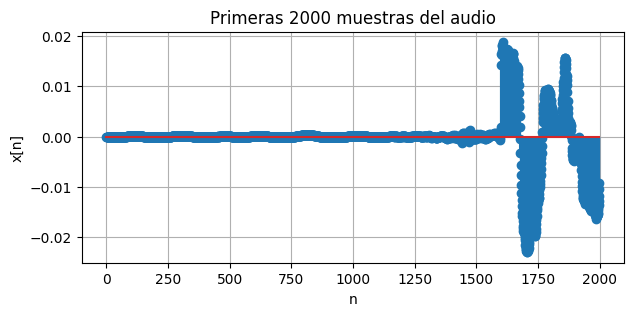

In [ ]:

# === Visualización (muestra corta) ===
# Graficamos solo las primeras N muestras para que se vea tipo DT.
N = 2000  # puedes cambiar
if audio is not None:
    n = np.arange(len(audio))
    stem_plot(n[:N], audio[:N], title=f"Primeras {N} muestras del audio")


1. Señal invertida: 


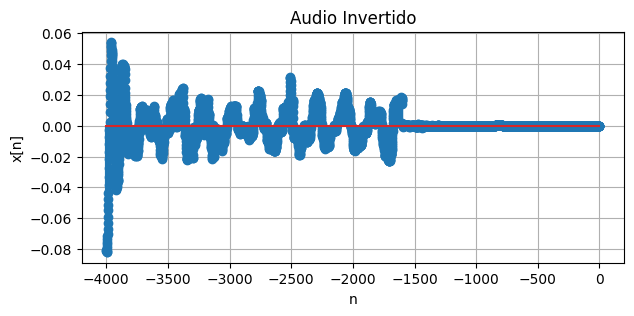



2. Señal desplazada (k=200)


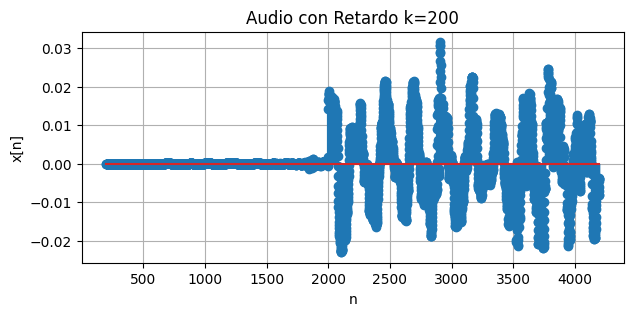



3. Energía original, invertida y desplazada
Energía Original:  0.4897
Energía Invertida: 0.4897
Energía Shifteada: 0.2563
Se observa que la energia original e invertida es la misma, mientras que la desplazada varia (es menor a la original) ya que hubo recortes en la señal


4. Submuestreo manual


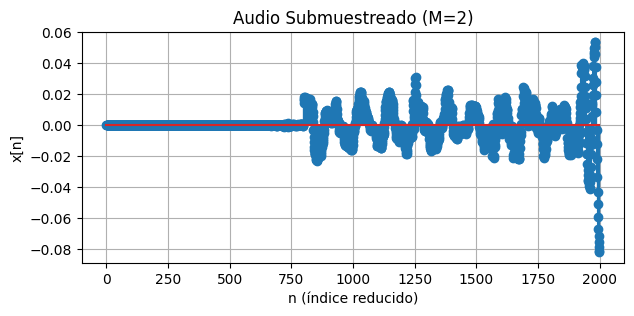

Energía Submuestreada (M=2): 0.243204
Tal como se observa, la energía se reduce porque se suman menos muestras de la señal original.


In [ ]:
# === Experimentos sugeridos (TODO) ===
# 1) Invertir: usa time_reverse(audio_short) sobre una ventana corta
print("1. Señal invertida: ")
ventana = 4000
audio_recorte = audio[:ventana]
audio_invertido = time_reverse(audio_recorte)
n_invertido = np.arange(-(ventana - 1), 1)
stem_plot(n_invertido, audio_invertido, title="Audio Invertido")
print("\n")

# 2) Corrimiento: aplica time_shift(..., k=200) (retardo) o k=-200 (adelanto)
print("2. Señal desplazada (k=200)")
retardo = 200
audio_shift = time_shift(audio_recorte, k=retardo)
n_shift = np.arange(ventana) + retardo
stem_plot(n_shift, audio_shift, title=f"Audio con Retardo k={retardo}")
print("\n")

# 3) Energía: compara energy(x) antes/después (¿cambia? ¿por qué?)
print("3. Energía original, invertida y desplazada")
E_orig = energy(audio_recorte)
E_inv = energy(audio_invertido)
E_shift = energy(audio_shift)

print(f"Energía Original:  {E_orig:.4f}")
print(f"Energía Invertida: {E_inv:.4f}")
print(f"Energía Shifteada: {E_shift:.4f}")
print("Se observa que la energia original e invertida es la misma, mientras que la desplazada varia (es menor a la original) ya que hubo recortes en la señal")
print("\n")

# 4) Submuestreo manual: crea x_ds = audio[::M] (aquí SÍ se permite slicing por submuestreo)
print("4. Submuestreo manual")
M = 2
audio_ds = audio_recorte[::M] #x[0], x[2], x[4], ... x[3998]
n_ds = np.arange(len(audio_ds))
stem_plot(n_ds, audio_ds, title=f"Audio Submuestreado (M={M})", xlabel="n (índice reducido)")

print(f"Energía Submuestreada (M={M}): {energy(audio_ds):.6f}")
print("Tal como se observa, la energía se reduce porque se suman menos muestras de la señal original.")